# Crop Leaf Disease Detection — V2 (No PCA)
**Fix:** Removed PCA. Reduced HOG resolution to (16,16) pixels_per_cell → raw features fed directly to Random Forest.

**Assumes data is already downloaded** in `./data/`

In [15]:
import os, glob, yaml
import cv2
import numpy as np
from skimage.feature import hog

# ---- Load class names from YAML ----
yaml_files = glob.glob("./data/**/*.yaml", recursive=True)
with open(yaml_files[0], "r") as f:
    data_config = yaml.safe_load(f)
class_names = data_config["names"]
print(f"Classes: {len(class_names)}")

# ---- Find image and label folders ----
image_folders = []
for root, dirs, _ in os.walk("./data"):
    for d in dirs:
        if d == "images":
            image_folders.append(os.path.join(root, d))
print(f"Image folders: {image_folders}")

Classes: 38
Image folders: ['./data/PlantVillage_for_object_detection/Dataset/images']


In [16]:
# ---- Feature Extraction (NO PCA, HOG at 16x16) ----

def extract_features(image):
    """Extract RGB, Grayscale Statistics, and HOG Textures with Gaussian Blur."""
    img_blurred = cv2.GaussianBlur(image, (5, 5), 0)
    img_resized = cv2.resize(img_blurred, (128, 128))

    # RGB Color Features
    b_mean, g_mean, r_mean = np.mean(img_resized, axis=(0, 1))
    b_std, g_std, r_std = np.std(img_resized, axis=(0, 1))

    # Grayscale Statistical Features
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    hist = np.histogram(gray, bins=256)[0]
    hist = hist / np.sum(hist)

    gray_features = [
        r_mean, g_mean, b_mean,
        r_std, g_std, b_std,
        np.mean(gray),
        np.std(gray),
        np.min(gray),
        np.max(gray),
        np.median(gray),
        np.var(gray),
        -np.sum(hist * np.log2(hist + 1e-7))
    ]

    # HOG at (16,16) pixels_per_cell → ~1,764 features instead of ~8,100
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    return np.hstack([gray_features, hog_features])


def get_class_from_label(label_path, class_names):
    """Read a YOLO label file and return the most common class name."""
    if not os.path.exists(label_path):
        return None
    with open(label_path, "r") as f:
        lines = f.readlines()
    if not lines:
        return None

    class_ids = []
    for line in lines:
        parts = line.strip().split()
        if parts:
            try:
                class_ids.append(int(parts[0]))
            except ValueError:
                continue

    if not class_ids:
        return None

    most_common = max(set(class_ids), key=class_ids.count)
    if most_common < len(class_names):
        return class_names[most_common]
    return f"class_{most_common}"

print("Functions defined.")

Functions defined.


In [17]:
# ---- Load all images and extract features ----
features = []
labels = []
class_counts = {}

for img_folder in image_folders:
    label_folder = img_folder.replace("images", "labels")
    if not os.path.exists(label_folder):
        print(f"  No label folder for {img_folder}, skipping")
        continue

    print(f"Processing: {img_folder}")
    for img_file in sorted(os.listdir(img_folder)):
        if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(img_folder, img_file)
        label_file = os.path.splitext(img_file)[0] + ".txt"
        label_path = os.path.join(label_folder, label_file)

        cls = get_class_from_label(label_path, class_names)
        if cls is None:
            continue

        image = cv2.imread(img_path)
        if image is None:
            continue

        feat = extract_features(image)
        features.append(feat)
        labels.append(cls)
        class_counts[cls] = class_counts.get(cls, 0) + 1

X, y = np.array(features), np.array(labels)
print(f"\nTotal samples: {len(X)}, Features per sample: {X.shape[1]}")
for cls, count in sorted(class_counts.items()):
    print(f"  {cls}: {count}")

Processing: ./data/PlantVillage_for_object_detection/Dataset/images

Total samples: 54293, Features per sample: 1777
  Apple___Apple_scab: 630
  Apple___Black_rot: 621
  Apple___Cedar_apple_rust: 275
  Apple___healthy: 1645
  Blueberry___healthy: 1502
  Cherry___Powdery_mildew: 1052
  Cherry___healthy: 853
  Corn___Cercospora_leaf_spot Gray_leaf_spot: 513
  Corn___Common_rust: 1192
  Corn___Northern_Leaf_Blight: 983
  Corn___healthy: 1157
  Grape___Black_rot: 1180
  Grape___Esca_(Black_Measles): 1383
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
  Grape___healthy: 423
  Orange___Haunglongbing_(Citrus_greening): 5507
  Peach___Bacterial_spot: 2297
  Peach___healthy: 360
  Pepper,_bell___Bacterial_spot: 997
  Pepper,_bell___healthy: 1477
  Potato___Early_blight: 1000
  Potato___Late_blight: 1000
  Potato___healthy: 152
  Raspberry___healthy: 371
  Soybean___healthy: 5089
  Squash___Powdery_mildew: 1835
  Strawberry___Leaf_scorch: 1109
  Strawberry___healthy: 456
  Tomato___Bacterial

In [18]:
# ---- Train/Test Split (NO PCA, NO Scaler) ----
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 43434, Test: 10859


In [19]:
# ---- Train Random Forest ----
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest (500 trees, max_depth=25, balanced)...")
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Training done.")

Training Random Forest (500 trees, max_depth=25, balanced)...
Training done.


In [20]:
# ---- Results ----
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*50}")
print(f"  ACCURACY: {accuracy:.2%}")
print(f"{'='*50}")

report = classification_report(y_test, y_pred)
print(f"\nClassification Report:\n")
print(report)

with open("classification_report_v2.txt", "w") as f:
    f.write(f"Accuracy: {accuracy:.2%}\n\n")
    f.write(f"Dataset: PlantVillage for Object Detection (YOLO format)\n")
    f.write(f"Total samples: {len(X)}\n")
    f.write(f"Features per sample: {X.shape[1]} (NO PCA, HOG 16x16)\n")
    f.write(f"Train: {len(X_train)}, Test: {len(X_test)}\n\n")
    f.write(report)
print("Saved classification_report_v2.txt")


  ACCURACY: 75.52%

Classification Report:

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.93      0.10      0.19       126
                            Apple___Black_rot       0.78      0.83      0.80       124
                     Apple___Cedar_apple_rust       0.00      0.00      0.00        55
                              Apple___healthy       0.60      0.42      0.49       329
                          Blueberry___healthy       0.71      0.85      0.77       300
                      Cherry___Powdery_mildew       0.89      0.75      0.81       210
                             Cherry___healthy       0.93      0.86      0.89       171
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.36      0.50       103
                           Corn___Common_rust       0.97      0.99      0.98       238
                  Corn___Northern_Leaf_Blight       0.65      0.80      0.72       1

/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


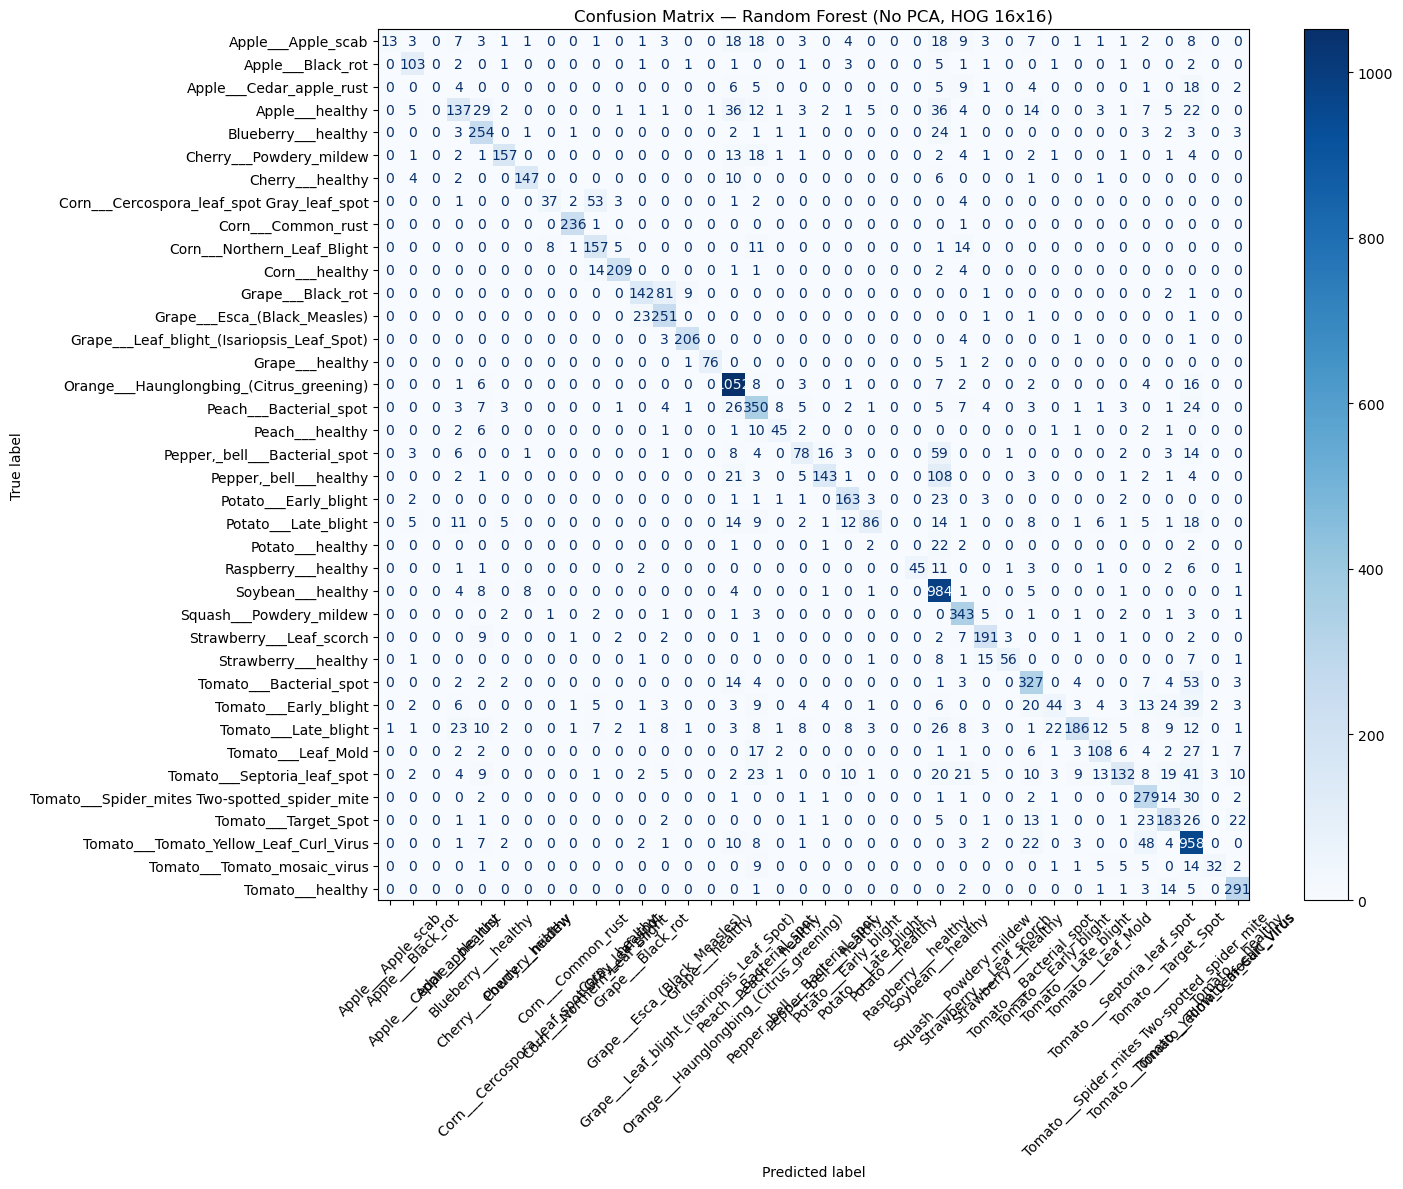

Saved confusion_matrix_v2.png


In [21]:
# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(15, 12))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Random Forest (No PCA, HOG 16x16)")
plt.tight_layout()
plt.savefig("confusion_matrix_v2.png", dpi=150)
plt.show()
print("Saved confusion_matrix_v2.png")

In [22]:
# ---- Save pipeline (model only, no scaler/PCA) ----
import joblib

model.n_jobs = 1

pipeline = {
    "model": model,
    "classes": model.classes_
}

joblib.dump(pipeline, "leaf_disease_pipeline_v2.pkl", compress=3)
size_mb = os.path.getsize("leaf_disease_pipeline_v2.pkl") / (1024 * 1024)
print(f"Saved leaf_disease_pipeline_v2.pkl ({size_mb:.1f} MB)")

Saved leaf_disease_pipeline_v2.pkl (445.6 MB)


In [23]:
print("DONE! Output files:")
print("  confusion_matrix_v2.png")
print("  classification_report_v2.txt")
print("  leaf_disease_pipeline_v2.pkl")

DONE! Output files:
  confusion_matrix_v2.png
  classification_report_v2.txt
  leaf_disease_pipeline_v2.pkl
